In [49]:
import numpy as np
import pandas as pd

# Load training data
data_train = pd.read_csv('/home/bigbang/machinelearning_algorithms/linear_regression_train.csv')
X_train = data_train.iloc[:, 1:-1].values  # Features
y = data_train.iloc[:, -1].values    # Target

# Load test data (no target column)
data_test = pd.read_csv('/home/bigbang/machinelearning_algorithms/linear_regression_test.csv')
X_test = data_test.iloc[:, 1:].values  # Features 

# Normalize training data
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

X = (X_train - X_train_mean) / X_train_std  # Standardize training features

# Normalize test data using training data's mean and std
X_test_normalized = (X_test - X_train_mean) / X_train_std

# Debugging: Check the first few rows of the test data after normalization
print("Test data before normalization:")
print(X_test[:5])  # Print first 5 rows of original test data

print("Test data after normalization:")
print(X_test_normalized[:5])  # Print first 5 rows of normalized test data



# Display the first few rows of the training data to confirm it's loaded correctly
print(X[:5])
print(y[:5])

Test data before normalization:
[[ -13.29664984   26.94791326   95.97781082  -25.16783084  -25.86338949
   -46.43254828  -30.12014781  -99.2205689   -95.77173028  141.76372297
    -5.08267472  -48.15721092 -109.24631489   99.21853027   49.83407347
   -46.27561644  -36.21102119   46.58853648   -1.14656739  -55.50421542
   -70.99317247  -13.51682572  -93.08558458  -10.31051873  -47.57996745]
 [  13.74047822   26.6323546    -1.05683434  113.38694994  -26.95718899
   -40.30557122   -8.91696814  -99.18278094  -65.65332265   39.50079274
   -32.5378726   -56.20056416  -47.8924449    97.50862704   42.96933628
   -53.96110025  -27.15398676  -20.94272432   -5.64880224  -27.80907584
  -151.02395948  -37.02080819  -99.35181737    7.80600033   75.69153932]
 [   5.75770087    5.72928201   -7.84631752    9.0637374   -54.52241059
   -17.10245688  -89.39151854  -81.82718331 -104.00716307   27.74045361
   -74.94574576  -32.84476777  -58.83620686  114.60993937   42.74196165
   -31.82247452  -89.09331882 

In [50]:
# Linear Regression with Gradient Descent
def LinReg_with_gradient_descent(X, y, alpha, epoch):
    m = X.shape[0]  # Number of samples
    ones = np.ones((m, 1))
    X = np.concatenate((ones, X), axis=1)  # Add bias term to feature matrix
    n = X.shape[1]
    w = np.ones(n)  # Initialize weights
    costs = []      # Store cost for each epoch

    def compute_cost(X, y, w):
        m = len(y)
        h = np.dot(X, w)
        cost = (1 / (2 * m)) * np.sum((h - y) ** 2)
        return cost

    for i in range(epoch):
        h = np.dot(X, w)  # Compute predictions
        gradient = (1 / m) * np.dot(X.T, (h - y))  # Compute gradient
        w = w - alpha * gradient  # Update weights

        # Compute and store cost
        cost = compute_cost(X, y, w)
        costs.append(cost)
        if i % 100 == 0:  # Print every 100 epochs
            print(f'Epoch {i}, Cost: {cost}')

    return w, costs

Epoch 0, Cost: 3034255.2881252286
Epoch 100, Cost: 461706.85591882747
Epoch 200, Cost: 112848.2992505943
Epoch 300, Cost: 65481.26900382066
Epoch 400, Cost: 59042.08590748868
Epoch 500, Cost: 58165.68828897383
Epoch 600, Cost: 58046.268475657154
Epoch 700, Cost: 58029.977528267125
Epoch 800, Cost: 58027.752672081624
Epoch 900, Cost: 58027.44848907032
Optimized weights: [ 1.24692495e+03  1.30438420e+02  6.37796459e-01  5.22726469e+02
  7.35302906e+02 -4.22793381e-01  8.11251156e+02  4.42182078e+02
 -1.00143565e+00  6.47162293e+02  2.25161412e+02  7.88231337e-01
  2.94034472e-01  7.62054046e+02  6.62188634e+02 -1.42336619e+00
  5.27362596e+02  3.16582355e+01  4.52241470e+02  4.12471339e+02
  6.94708609e+02  9.67701967e+01  1.15450973e+00  1.05482820e+02
  4.92006122e+02  8.02966597e-01]


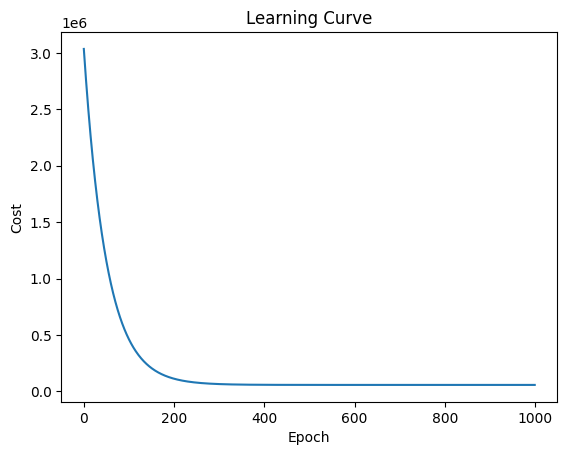

In [51]:
# Train the model
alpha = 0.01  # Learning rate
epoch = 1000  # Number of iterations

# Call the gradient descent function to optimize weights
w_optimized, costs = LinReg_with_gradient_descent(X, y, alpha, epoch)

# Display the optimized weights
print("Optimized weights:", w_optimized)

# Plot the learning curve (cost vs epochs)
import matplotlib.pyplot as plt
plt.plot(range(epoch), costs)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Learning Curve')
plt.show()

In [52]:
# Make predictions on the test set using the optimized weights
def predict(X, w):
    m = X.shape[0]
    ones = np.ones((m, 1))
    X = np.concatenate((ones, X), axis=1)  # Add bias term
    return np.dot(X, w)  # Predicted values

# Get predictions

y_pred = predict(X_test_normalized, w_optimized)
y_train_pred = predict(X,w_optimized)

# Display the first few predictions
print("Predictions: ", y_pred[:5]) 
print("Predictions train: ", y_train_pred[:5]) # Print first 5 predictions

Predictions:  [ 1067.94601746  4496.68748006  4051.15998803 -1318.48927911
   745.40922535]
Predictions train:  [ 4843.57179934 -1070.66525723 -1075.50613789   124.38534535
  1017.14136118]
